# Chapter 13 example: Gaussian belief propagation and walk-summability

A Gaussian graphical model has density

$$
p(x)\propto\exp\left(-\frac12 x^T Jx+h^Tx\right),
$$

with exact mean $\mu=J^{-1}h$ and covariance $\Sigma=J^{-1}$. Gaussian BP propagates quadratic messages. On walk-summable models it converges and yields exact means; its variance behavior is more subtle.

We scale the off-diagonal couplings and compare BP convergence with the walk-summability diagnostic $\rho(|R|)<1$, where $J=D^{1/2}(I-R)D^{1/2}$.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
n=6; edges=[(0,1),(1,2),(2,3),(3,4),(4,5),(0,5),(1,4)]
base={(0,1):-.22,(1,2):.18,(2,3):-.20,(3,4):.16,(4,5):-.19,(0,5):.14,(1,4):-.12}
h=np.array([.5,-.2,.15,.3,-.1,.25])
def makeJ(scale):
 J=np.eye(n)*1.35
 for (i,j),v in base.items(): J[i,j]=J[j,i]=scale*v
 return J
def walk_rho(J):
 D=np.diag(np.diag(J)); Di=np.diag(1/np.sqrt(np.diag(J))); R=np.eye(n)-Di@J@Di; return max(abs(np.linalg.eigvals(abs(R))))
def gabp(J,maxit=500,tol=1e-10):
 neigh={i:[] for i in range(n)}
 for i,j in edges: neigh[i].append(j); neigh[j].append(i)
 P={(i,j):0. for i in range(n) for j in neigh[i]}; u={(i,j):0. for i in range(n) for j in neigh[i]}
 hist=[]
 for it in range(maxit):
  Pn={}; un={}
  for i in range(n):
   for j in neigh[i]:
    cavity=J[i,i]+sum(P[(k,i)] for k in neigh[i] if k!=j)
    eta=h[i]+sum(u[(k,i)] for k in neigh[i] if k!=j)
    Pn[(i,j)]=-(J[i,j]**2)/cavity
    un[(i,j)]=-(J[i,j]*eta)/cavity
  delta=max(max(abs(Pn[e]-P[e]),abs(un[e]-u[e])) for e in P)
  P,u=Pn,un; hist.append(delta)
  if not np.isfinite(delta) or delta>1e8: return None,hist
  if delta<tol: break
 mu=np.zeros(n)
 var=np.zeros(n)
 for i in range(n):
  prec=J[i,i]+sum(P[(k,i)] for k in neigh[i]); eta=h[i]+sum(u[(k,i)] for k in neigh[i]); mu[i]=eta/prec; var[i]=1/prec
 return (mu,var),hist

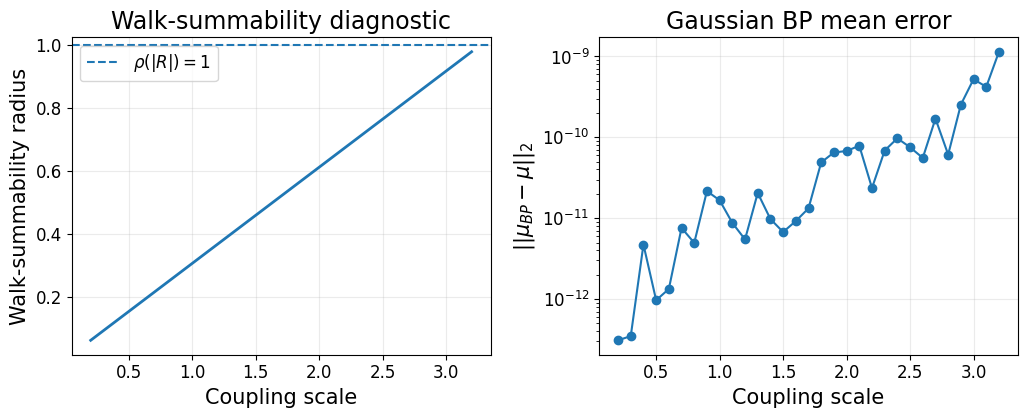

In [3]:
scales=np.linspace(.2,3.2,31); rhos=[]; errors=[]; iters=[]
for s in scales:
 J=makeJ(s); rhos.append(walk_rho(J)); exact=np.linalg.solve(J,h) if np.all(np.linalg.eigvalsh(J)>0) else None; out,hist=gabp(J)
 if exact is None or out is None: errors.append(np.nan); iters.append(np.nan)
 else: errors.append(np.linalg.norm(out[0]-exact)); iters.append(len(hist))
fig,axes=plt.subplots(1,2,figsize=(10.5,4.4)); axes[0].plot(scales,rhos,linewidth=2); axes[0].axhline(1,linestyle='--',label=r'$\rho(|R|)=1$'); axes[0].set_xlabel('Coupling scale'); axes[0].set_ylabel('Walk-summability radius'); axes[0].set_title('Walk-summability diagnostic'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].semilogy(scales,errors,marker='o'); axes[1].set_xlabel('Coupling scale'); axes[1].set_ylabel(r'$||\mu_{BP}-\mu||_2$'); axes[1].set_title('Gaussian BP mean error'); axes[1].grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch13_02_walk_summability_and_bp'); plt.show()

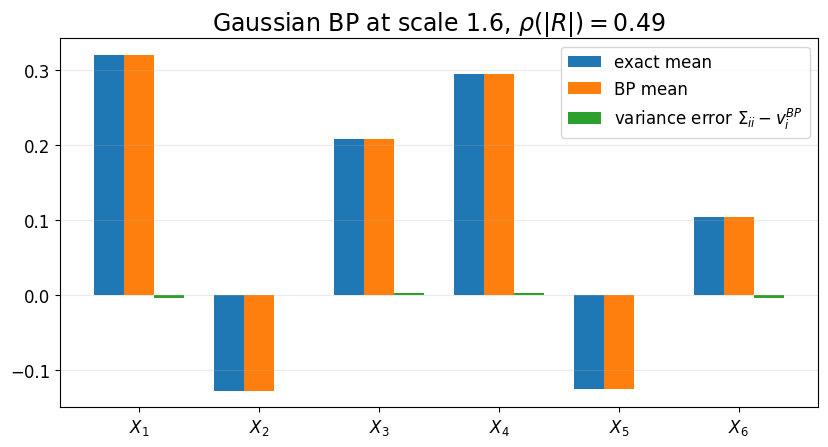

In [4]:
s=1.6; J=makeJ(s); out,hist=gabp(J); mu,var=out; exact_mu=np.linalg.solve(J,h); exact_var=np.diag(np.linalg.inv(J))
fig,ax=plt.subplots(figsize=(8.5,4.7)); x=np.arange(n); w=.25; ax.bar(x-w,exact_mu,w,label='exact mean'); ax.bar(x,mu,w,label='BP mean'); ax.bar(x+w,exact_var-var,w,label=r'variance error $\Sigma_{ii}-v_i^{BP}$'); ax.set_xticks(x,[rf'$X_{i+1}$' for i in range(n)]); ax.set_title(rf'Gaussian BP at scale {s:.1f}, $\rho(|R|)={walk_rho(J):.2f}$'); ax.grid(axis='y',alpha=.25); ax.legend(); fig.tight_layout(); save_figure(fig,'ch13_02_exact_vs_bp_moments'); plt.show()

## Exercises

1. Remove the chord $(1,4)$ and verify exactness on the resulting single cycle/tree variants.
2. Compare the BP variance with the exact diagonal of $J^{-1}$ as the coupling scale increases.
3. **Challenge.** Add damping to the message updates and search for parameter regimes in which undamped BP diverges but damped BP converges. Distinguish empirical convergence from a theoretical guarantee.